# Week 8 Jupyter Notebook — K-Nearest Neighbors and Distance Metrics  
## Integrated Capstone Project: Wisconsin and Coimbra Breast Cancer Datasets

**Week topic:** K-Nearest Neighbors and distance metrics

### Notebook purpose

For Week 8, I am applying **K-Nearest Neighbors (KNN)** to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements such as radius, texture, perimeter, area, smoothness, and concavity.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I am not merging these datasets because they are not from the same patients and do not have the same variables. Instead, I use them side-by-side to compare how a distance-based model behaves on two different types of breast cancer data.

This notebook focuses on:

- K-Nearest Neighbors classification
- Feature scaling for distance-based models
- Different values of `k`
- Distance metrics: Euclidean, Manhattan, Minkowski, and Chebyshev
- Uniform versus distance-weighted neighbors
- Cross-validation and hyperparameter tuning
- Comparison of Wisconsin and Coimbra results


## 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 2. Why KNN needs scaling

KNN is a distance-based model. It classifies a new observation by looking at the closest training observations. Because of that, feature scaling is very important.

If one feature has a much larger numeric range than another feature, it can dominate the distance calculation. For example, tumor area or MCP-1 may have much larger values than smoothness or BMI. Without scaling, KNN may treat large-scale variables as more important just because of their units.

In this notebook, I compare KNN with and without scaling, but I expect the scaled versions to be more appropriate.


## 3. Helper functions

I use the same helper functions for both datasets so the comparison is consistent.

In [ ]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    """Fit a classifier and return common binary classification metrics."""
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_positive": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_positive": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_positive": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_pred, test_pred, train_prob, test_prob


def plot_decision_boundary(model, X_data, y_data, title, class_labels, x_pad=1, y_pad=1):
    """Plot a 2-feature decision boundary for a fitted classifier pipeline."""
    x_min, x_max = X_data.iloc[:, 0].min() - x_pad, X_data.iloc[:, 0].max() + x_pad
    y_min, y_max = X_data.iloc[:, 1].min() - y_pad, X_data.iloc[:, 1].max() + y_pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid_points = pd.DataFrame({
        X_data.columns[0]: xx.ravel(),
        X_data.columns[1]: yy.ravel()
    })

    Z = model.predict(grid_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)

    for class_value, label in class_labels:
        plt.scatter(
            X_data.iloc[y_data.values == class_value, 0],
            X_data.iloc[y_data.values == class_value, 1],
            label=label,
            alpha=0.8
        )

    plt.xlabel(X_data.columns[0])
    plt.ylabel(X_data.columns[1])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_knn_workflow(dataset_name, df, feature_cols, target_col, label_col, positive_class_name, negative_class_name, two_feature_cols):
    """Run the Week 8 KNN workflow for one dataset."""
    print("=" * 80)
    print(f"KNN workflow for {dataset_name}")
    print("=" * 80)

    X = df[feature_cols]
    y = df[target_col]

    print("Dataset shape:", df.shape)
    print("Number of features:", X.shape[1])
    print("\nClass counts:")
    print(df[label_col].value_counts())
    print("\nClass percentages:")
    print(df[label_col].value_counts(normalize=True).round(3))

    # EDA: correlations with target
    corr_with_target = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
    corr_sorted = corr_with_target.sort_values()

    plt.figure(figsize=(9, 6))
    plt.barh(corr_sorted.index, corr_sorted.values)
    plt.xlabel(f"Correlation With {positive_class_name}")
    plt.title(f"{dataset_name}: Feature Correlations With Target")
    plt.tight_layout()
    plt.show()

    # EDA: feature ranges
    scale_summary = X.agg(["min", "max", "mean", "std"]).T
    scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
    scale_summary_plot = scale_summary.sort_values("range", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(scale_summary_plot.index, scale_summary_plot["range"])
    plt.xlabel("Feature Range")
    plt.title(f"{dataset_name}: Feature Ranges Before Scaling")
    plt.tight_layout()
    plt.show()

    display(scale_summary.sort_values("range", ascending=False))

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("\nTraining shape:", X_train.shape)
    print("Testing shape:", X_test.shape)

    # Baseline no scaling
    knn_no_scaling = Pipeline(steps=[
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    no_scaling_results, no_scaling_train_pred, no_scaling_test_pred, no_scaling_train_prob, no_scaling_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: No Scaling, k=5",
        knn_no_scaling,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # Standard scaling
    knn_standard = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    standard_results, standard_train_pred, standard_test_pred, standard_train_prob, standard_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: Standard Scaled, k=5",
        knn_standard,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # Min-max scaling
    knn_minmax = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    minmax_results, minmax_train_pred, minmax_test_pred, minmax_train_prob, minmax_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: Min-Max Scaled, k=5",
        knn_minmax,
        X_train,
        X_test,
        y_train,
        y_test
    )

    scaling_results_df = pd.DataFrame([
        no_scaling_results,
        standard_results,
        minmax_results
    ]).sort_values("test_roc_auc", ascending=False)

    print("\nScaling comparison:")
    display(scaling_results_df)

    plt.figure(figsize=(9, 5))
    plt.bar(scaling_results_df["model"], scaling_results_df["test_roc_auc"])
    plt.ylabel("Test ROC-AUC")
    plt.title(f"{dataset_name}: KNN Scaling Comparison by ROC-AUC")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # Hyperparameter tuning
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    tuned_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])

    knn_param_grid = [
        {
            "model__n_neighbors": list(range(1, 22, 2)),
            "model__weights": ["uniform", "distance"],
            "model__metric": ["minkowski"],
            "model__p": [1, 2]
        },
        {
            "model__n_neighbors": list(range(1, 22, 2)),
            "model__weights": ["uniform", "distance"],
            "model__metric": ["chebyshev"]
        }
    ]

    grid = GridSearchCV(
        estimator=tuned_pipe,
        param_grid=knn_param_grid,
        scoring="recall",
        cv=cv,
        n_jobs=1
    )

    grid.fit(X_train, y_train)

    print("\nBest KNN parameters:")
    print(grid.best_params_)
    print("Best cross-validated recall:", grid.best_score_)

    tuned_results, tuned_train_pred, tuned_test_pred, tuned_train_prob, tuned_test_prob = evaluate_classifier(
        f"{dataset_name} Tuned KNN",
        grid.best_estimator_,
        X_train,
        X_test,
        y_train,
        y_test
    )

    model_results_df = pd.DataFrame([
        no_scaling_results,
        standard_results,
        minmax_results,
        tuned_results
    ]).sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])

    print("\nKNN model comparison:")
    display(model_results_df)

    # k sensitivity
    k_results = []

    for k in range(1, 32, 2):
        model = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2))
        ])

        recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

        k_results.append({
            "k": k,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

    k_results_df = pd.DataFrame(k_results)

    plt.figure(figsize=(8, 5))
    plt.plot(k_results_df["k"], k_results_df["CV_recall_mean"], marker="o", label="Recall")
    plt.plot(k_results_df["k"], k_results_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Cross-Validated Score")
    plt.title(f"{dataset_name}: KNN Sensitivity to k")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Distance metric comparison
    best_k = grid.best_params_["model__n_neighbors"]

    metric_models = {
        "Euclidean": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2))
        ]),
        "Manhattan": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=1))
        ]),
        "Chebyshev": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="chebyshev"))
        ])
    }

    metric_results = []

    for metric_name, model in metric_models.items():
        recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

        metric_results.append({
            "distance_metric": metric_name,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

    metric_results_df = pd.DataFrame(metric_results).sort_values("CV_recall_mean", ascending=False)

    print("\nDistance metric comparison:")
    display(metric_results_df)

    plt.figure(figsize=(8, 5))
    plt.bar(metric_results_df["distance_metric"], metric_results_df["CV_recall_mean"], yerr=metric_results_df["CV_recall_std"], capsize=4)
    plt.ylabel("Cross-Validated Recall")
    plt.title(f"{dataset_name}: KNN Distance Metric Comparison")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    # Final evaluation
    print("\nClassification report for tuned KNN:")
    print(classification_report(y_test, tuned_test_pred, target_names=[negative_class_name, positive_class_name]))

    cm = confusion_matrix(y_test, tuned_test_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[negative_class_name, positive_class_name]
    )
    disp.plot()
    plt.title(f"{dataset_name}: Confusion Matrix for Tuned KNN")
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
    plt.title(f"{dataset_name}: ROC Curve for Tuned KNN")
    plt.tight_layout()
    plt.show()

    # 2-feature visualization
    X_two = df[two_feature_cols]
    y_two = df[target_col]

    X_two_train, X_two_test, y_two_train, y_two_test = train_test_split(
        X_two,
        y_two,
        test_size=0.20,
        random_state=42,
        stratify=y_two
    )

    two_feature_model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k))
    ])

    two_feature_model.fit(X_two_train, y_two_train)

    print("\nTwo-feature KNN accuracy:", accuracy_score(y_two_test, two_feature_model.predict(X_two_test)))

    plot_decision_boundary(
        two_feature_model,
        X_two,
        y_two,
        f"{dataset_name}: KNN Decision Regions Using Two Features",
        [(0, negative_class_name), (1, positive_class_name)],
        x_pad=1 if dataset_name == "Wisconsin" else 5,
        y_pad=0.05 if dataset_name == "Wisconsin" else 5
    )

    return {
        "dataset_name": dataset_name,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "grid": grid,
        "results_df": model_results_df,
        "k_results_df": k_results_df,
        "metric_results_df": metric_results_df,
        "tuned_results": tuned_results,
        "best_params": grid.best_params_
    }


# Part A: Breast Cancer Wisconsin Diagnostic Dataset

## 4. Load and prepare Wisconsin dataset

The sklearn version of this dataset originally uses `0 = malignant` and `1 = benign`. I switch it so the positive class is malignant diagnosis:

- `diagnosis_malignant = 1` for malignant tumors
- `diagnosis_malignant = 0` for benign tumors


In [ ]:
cancer = load_breast_cancer()

wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")

wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

wisconsin_features = [
    col for col in wisconsin_df.columns
    if col not in ["diagnosis_malignant", "diagnosis_label"]
]

wisconsin_df.head()


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


## 5. Run KNN workflow for Wisconsin

For Wisconsin, the two-feature visualization uses `mean_radius` and `mean_concavity`. These features were useful in earlier notebooks because they relate to tumor size and shape.

KNN workflow for Wisconsin
Dataset shape: (569, 32)
Number of features: 30

Class counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Class percentages:
diagnosis_label
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


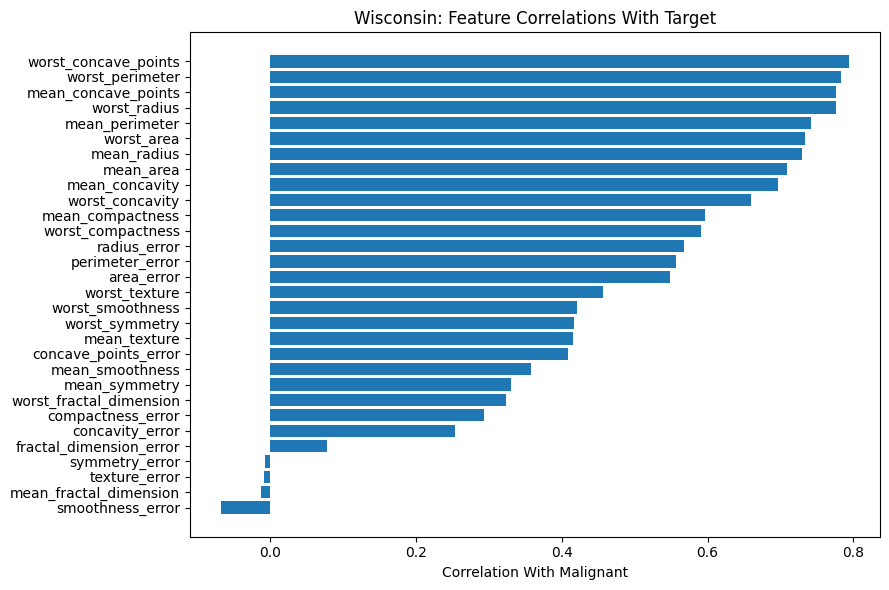

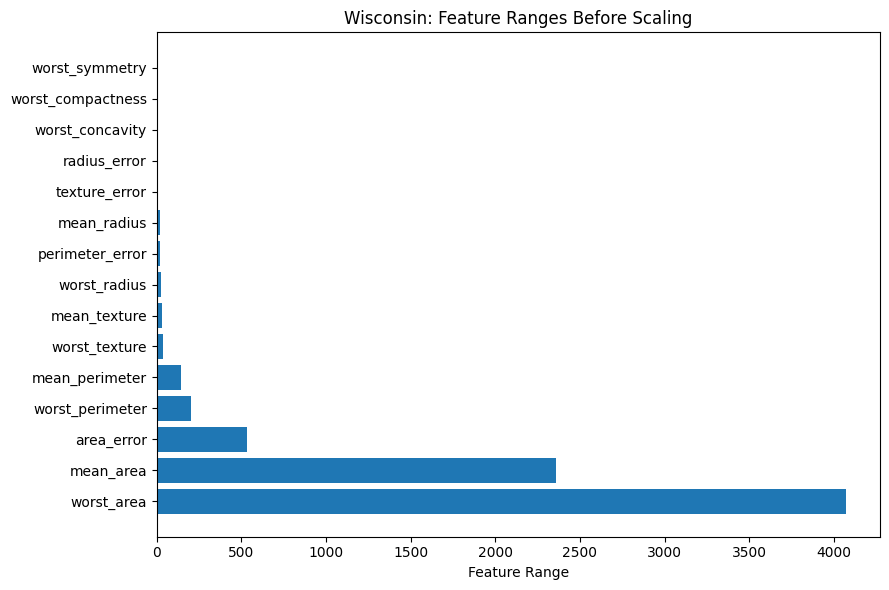

,min,max,mean,std,range
worst_area,185.200000,4254.00000,880.583128,569.356993,4068.800000
mean_area,143.500000,2501.00000,654.889104,351.914129,2357.500000
area_error,6.802000,542.20000,40.337079,45.491006,535.398000
worst_perimeter,50.410000,251.20000,107.261213,33.602542,200.790000
mean_perimeter,43.790000,188.50000,91.969033,24.298981,144.710000
worst_texture,12.020000,49.54000,25.677223,6.146258,37.520000
mean_texture,9.710000,39.28000,19.289649,4.301036,29.570000
worst_radius,7.930000,36.04000,16.269190,4.833242,28.110000
perimeter_error,0.757000,21.98000,2.866059,2.021855,21.223000
mean_radius,6.981000,28.11000,14.127292,3.524049,21.129000



Training shape: (455, 30)
Testing shape: (114, 30)

Scaling comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308
0,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696


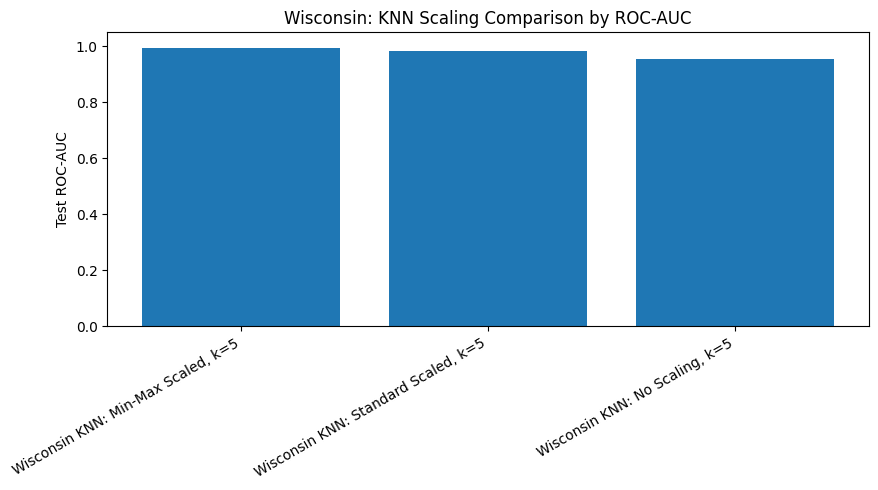


Best KNN parameters:
{'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
Best cross-validated recall: 0.9470588235294117

KNN model comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308
3,Wisconsin Tuned KNN,0.984615,0.964912,1.000000,0.904762,0.950000,0.973545
0,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696


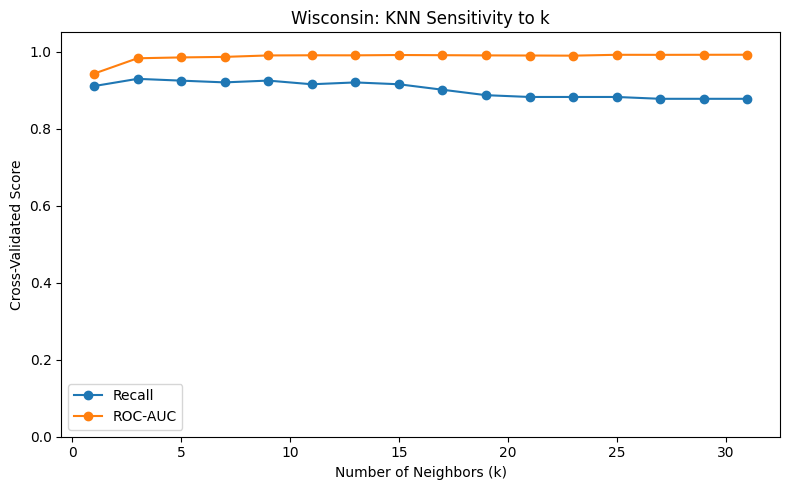


Distance metric comparison:


,distance_metric,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,Manhattan,0.938538,0.051006,0.983346,0.015528
0,Euclidean,0.929236,0.049531,0.982643,0.013364
2,Chebyshev,0.896346,0.043343,0.968564,0.017692


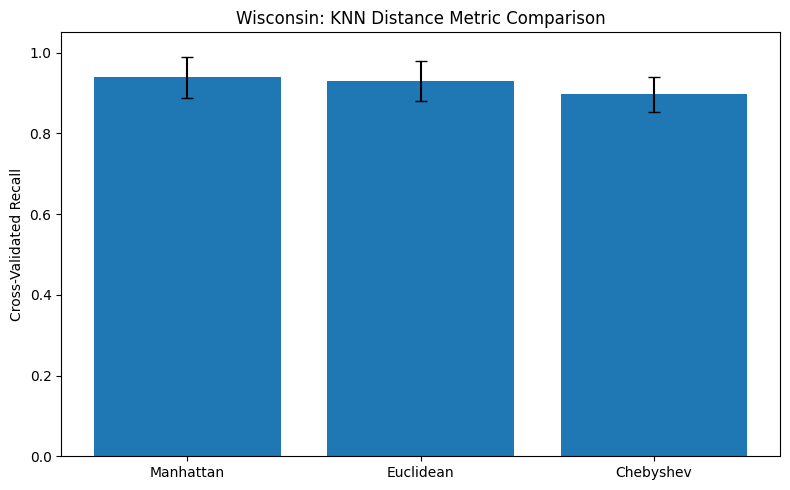


Classification report for tuned KNN:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



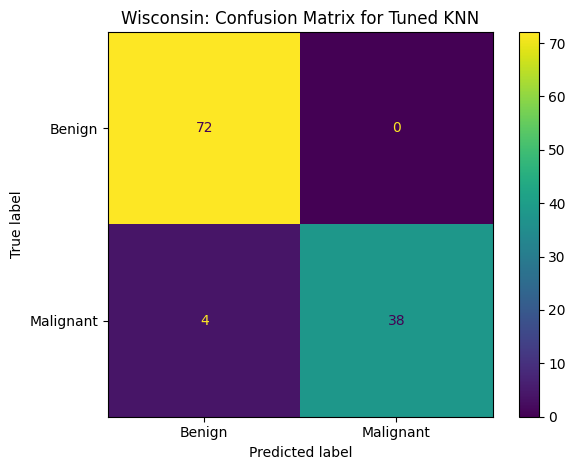

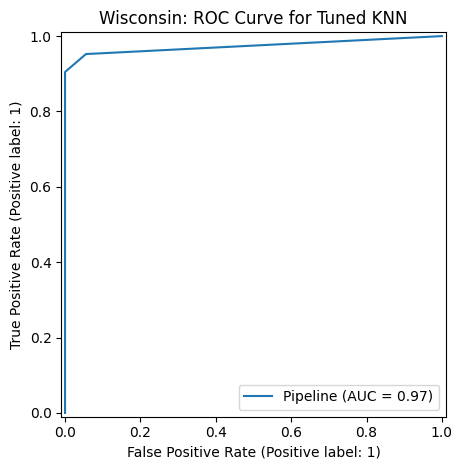


Two-feature KNN accuracy: 0.9122807017543859


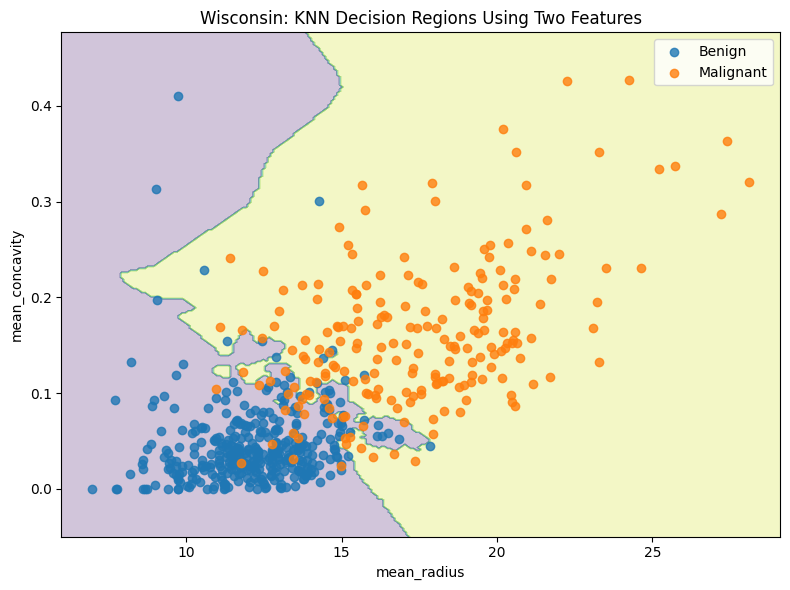

In [ ]:
wisconsin_results = run_knn_workflow(
    dataset_name="Wisconsin",
    df=wisconsin_df,
    feature_cols=wisconsin_features,
    target_col="diagnosis_malignant",
    label_col="diagnosis_label",
    positive_class_name="Malignant",
    negative_class_name="Benign",
    two_feature_cols=["mean_radius", "mean_concavity"]
)


### Wisconsin KNN interpretation

For Wisconsin, I expected KNN to perform well because the tumor measurements show strong separation between benign and malignant cases. Features like radius, perimeter, area, and concavity create meaningful distance patterns.

The key lesson is that scaling matters. Since KNN calculates distances, unscaled tumor area or perimeter could dominate the model just because those features have larger numeric values. Tuning `k` also matters because a small `k` can overfit, while a very large `k` can smooth too much and underfit.


# Part B: Breast Cancer Coimbra Dataset

## 6. Load and prepare Coimbra dataset

The Coimbra dataset target is called `Classification`. The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls


In [ ]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", "breast_cancer_present", "diagnosis_group"]
]

coimbra_df.head()


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 7. Run KNN workflow for Coimbra

For Coimbra, the two-feature visualization uses `Glucose` and `Resistin`. These are not the only important predictors, but they help show how KNN creates decision regions with clinical biomarkers.

KNN workflow for Coimbra
Dataset shape: (116, 12)
Number of features: 9

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64


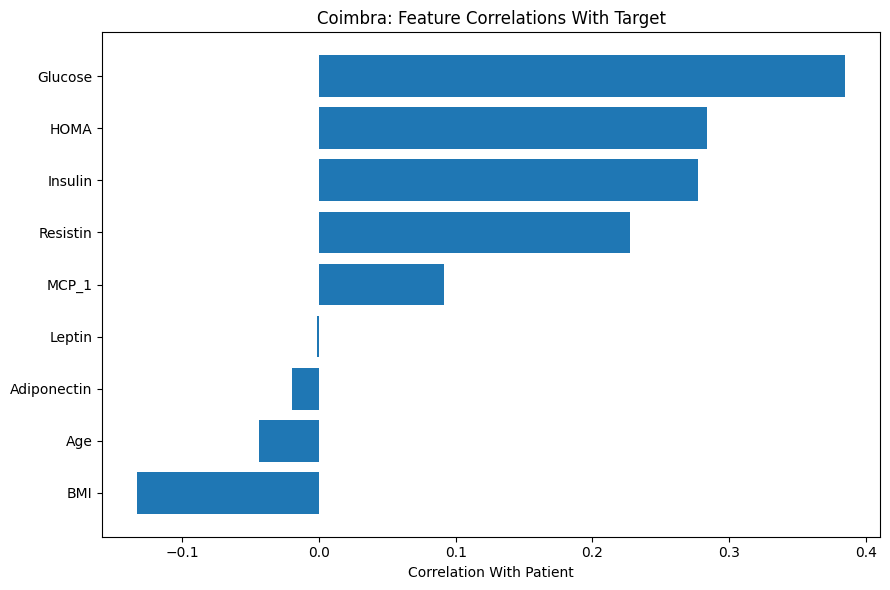

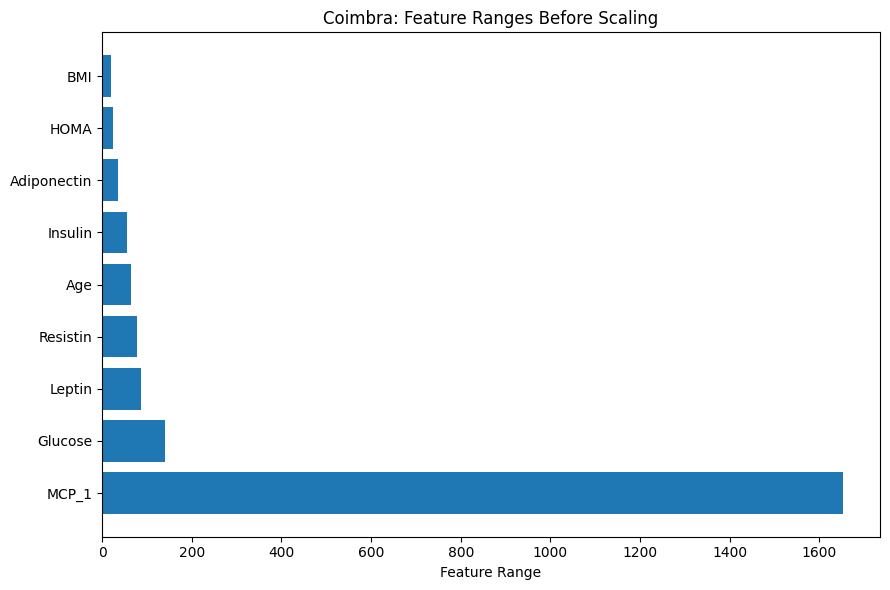

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759



Training shape: (92, 9)
Testing shape: (24, 9)

Scaling comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
1,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650
2,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168
0,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448


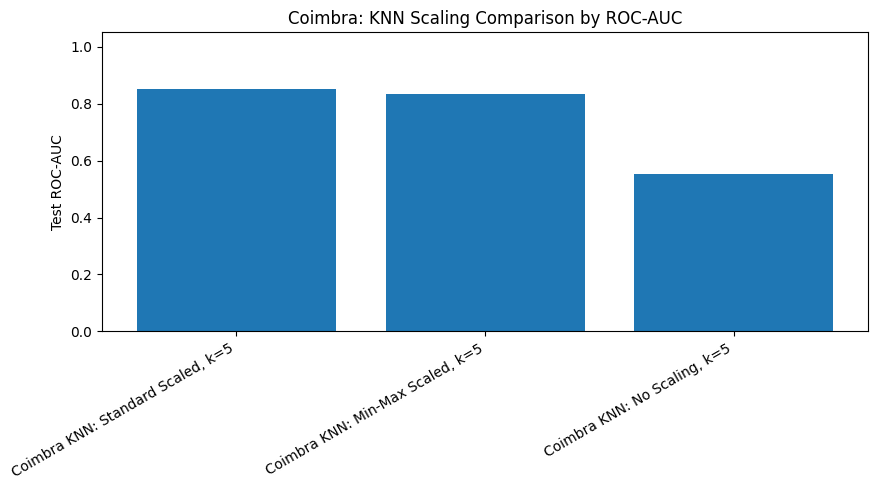


Best KNN parameters:
{'model__metric': 'chebyshev', 'model__n_neighbors': 19, 'model__weights': 'uniform'}
Best cross-validated recall: 0.8036363636363635

KNN model comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168
1,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650
3,Coimbra Tuned KNN,0.728261,0.666667,0.666667,0.769231,0.714286,0.685315
0,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448


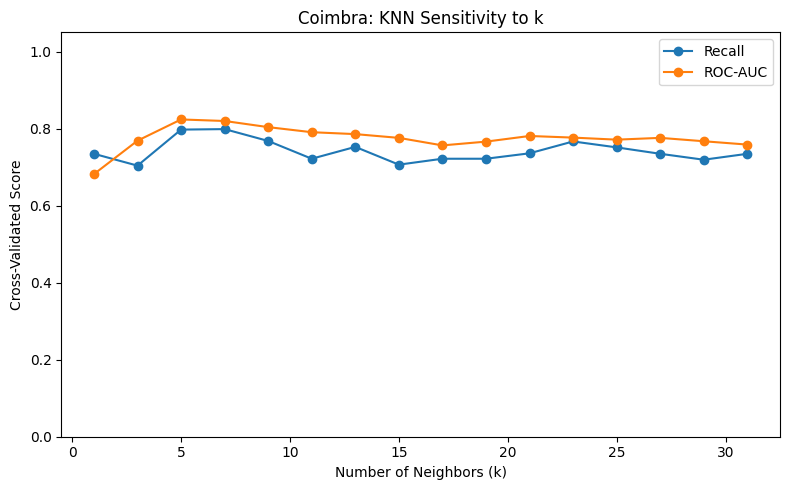


Distance metric comparison:


,distance_metric,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
2,Chebyshev,0.766667,0.095390,0.720082,0.087479
0,Euclidean,0.721795,0.112908,0.766224,0.084958
1,Manhattan,0.720513,0.140535,0.829825,0.093931


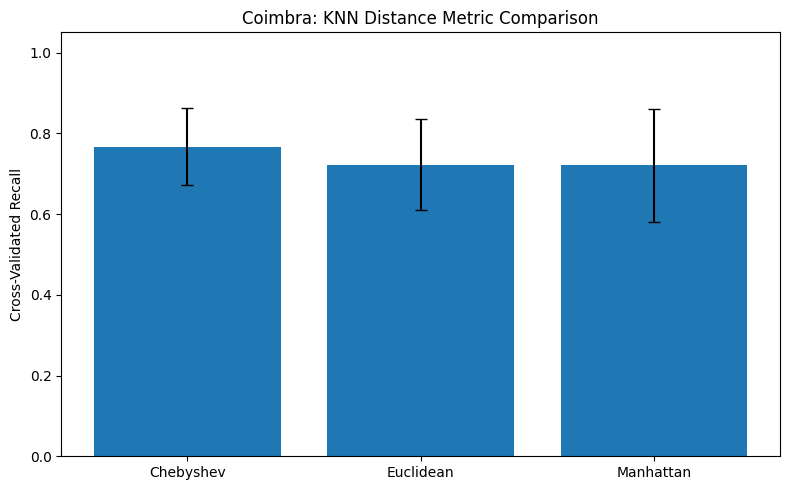


Classification report for tuned KNN:
                 precision    recall  f1-score   support

Healthy Control       0.67      0.55      0.60        11
        Patient       0.67      0.77      0.71        13

       accuracy                           0.67        24
      macro avg       0.67      0.66      0.66        24
   weighted avg       0.67      0.67      0.66        24



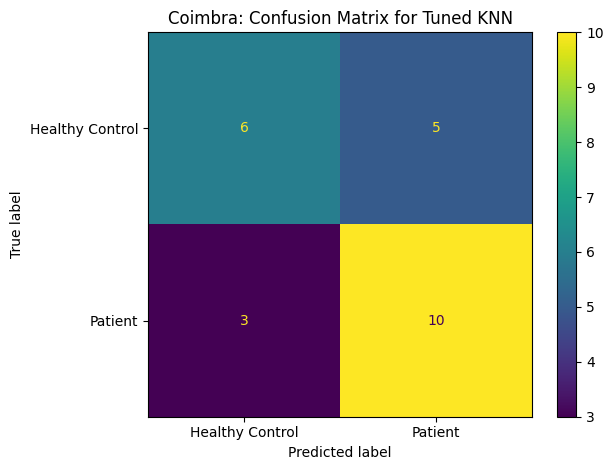

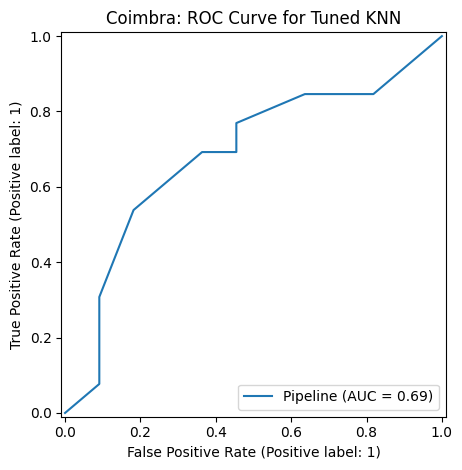


Two-feature KNN accuracy: 0.6666666666666666


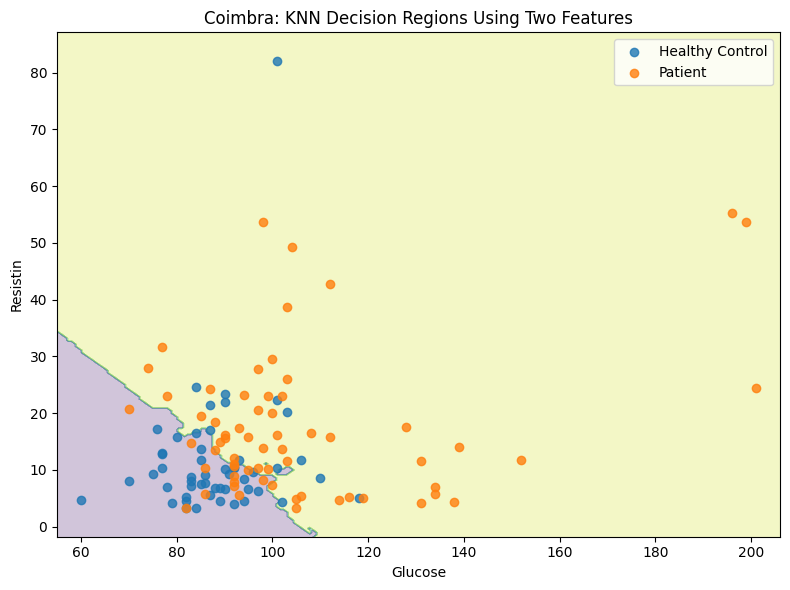

In [ ]:
coimbra_results = run_knn_workflow(
    dataset_name="Coimbra",
    df=coimbra_df,
    feature_cols=coimbra_features,
    target_col="breast_cancer_present",
    label_col="diagnosis_group",
    positive_class_name="Patient",
    negative_class_name="Healthy Control",
    two_feature_cols=["Glucose", "Resistin"]
)


### Coimbra KNN interpretation

For Coimbra, I expected KNN to be more challenging than Wisconsin because the dataset is smaller and the predictors are more indirect. KNN can still be useful because it compares similar patient profiles based on distance.

However, because Coimbra has fewer rows, the value of `k` and the distance metric can have a larger effect on the results. Cross-validation is important because one train-test split may not be stable enough.


# Part C: Week 8 Comparison Across Both Datasets

## 8. Compare Wisconsin and Coimbra KNN results

In [ ]:
wisconsin_knn_results_df = wisconsin_results["results_df"].copy()
wisconsin_knn_results_df["dataset"] = "Wisconsin"

coimbra_knn_results_df = coimbra_results["results_df"].copy()
coimbra_knn_results_df["dataset"] = "Coimbra"

week8_combined_results = pd.concat(
    [wisconsin_knn_results_df, coimbra_knn_results_df],
    ignore_index=True
)

week8_combined_results.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc,dataset
0,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701,Wisconsin
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308,Wisconsin
2,Wisconsin Tuned KNN,0.984615,0.964912,1.000000,0.904762,0.950000,0.973545,Wisconsin
4,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168,Coimbra
3,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696,Wisconsin
5,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650,Coimbra
6,Coimbra Tuned KNN,0.728261,0.666667,0.666667,0.769231,0.714286,0.685315,Coimbra
7,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448,Coimbra


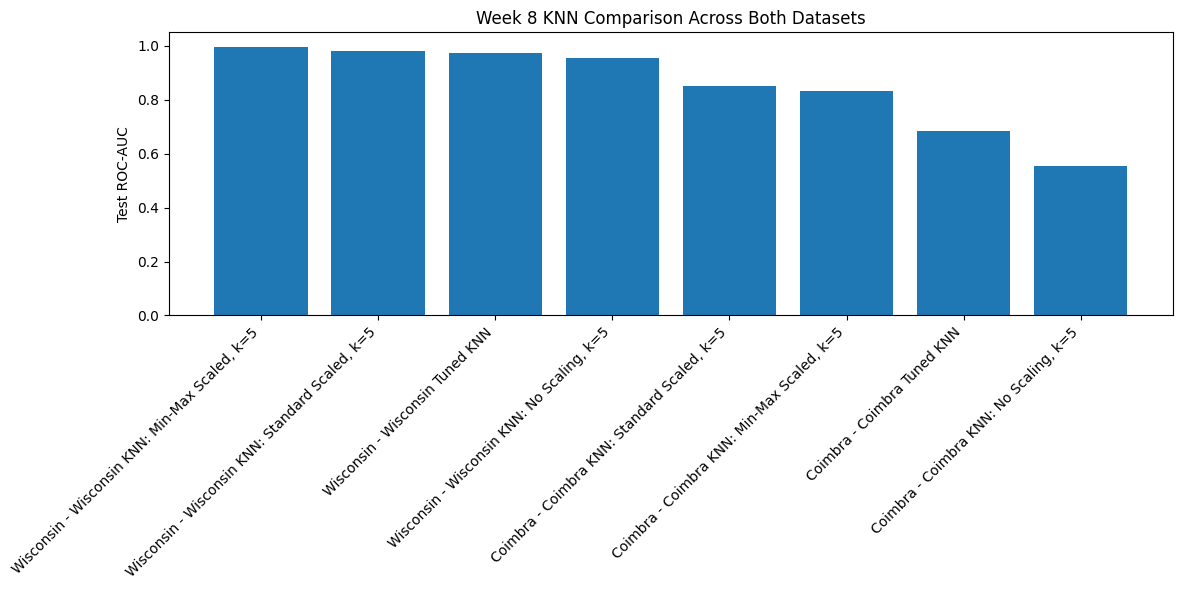

In [ ]:
# Combined model comparison by ROC-AUC
plot_df = week8_combined_results.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset"] + " - " + plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Week 8 KNN Comparison Across Both Datasets")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 9. Week 8 summary

This cell prints a short summary using the actual notebook results. I can use this later when writing Milestone Two.

In [ ]:
best_w_knn = wisconsin_knn_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_knn = coimbra_knn_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

print("Week 8 KNN Summary")


print("Best Wisconsin KNN model:")
print(best_w_knn["model"])
print(f"Test accuracy: {best_w_knn['test_accuracy']:.4f}")
print(f"Test recall for malignant cases: {best_w_knn['test_recall_positive']:.4f}")
print(f"Test precision for malignant cases: {best_w_knn['test_precision_positive']:.4f}")
print(f"Test F1: {best_w_knn['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_w_knn['test_roc_auc']:.4f}")

print("\nBest Coimbra KNN model:")
print(best_c_knn["model"])
print(f"Test accuracy: {best_c_knn['test_accuracy']:.4f}")
print(f"Test recall for patients: {best_c_knn['test_recall_positive']:.4f}")
print(f"Test precision for patients: {best_c_knn['test_precision_positive']:.4f}")
print(f"Test F1: {best_c_knn['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_c_knn['test_roc_auc']:.4f}")

print("\nBest Wisconsin KNN hyperparameters:")
print(wisconsin_results["best_params"])

print("\nBest Coimbra KNN hyperparameters:")
print(coimbra_results["best_params"])


Week 8 KNN Summary
Best Wisconsin KNN model:
Wisconsin KNN: Min-Max Scaled, k=5
Test accuracy: 0.9561
Test recall for malignant cases: 0.9048
Test precision for malignant cases: 0.9744
Test F1: 0.9383
Test ROC-AUC: 0.9957

Best Coimbra KNN model:
Coimbra KNN: Min-Max Scaled, k=5
Test accuracy: 0.7917
Test recall for patients: 0.8462
Test precision for patients: 0.7857
Test F1: 0.8148
Test ROC-AUC: 0.8322

Best Wisconsin KNN hyperparameters:
{'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}

Best Coimbra KNN hyperparameters:
{'model__metric': 'chebyshev', 'model__n_neighbors': 19, 'model__weights': 'uniform'}


## 10. Week 8 findings and interpretation

After running this Week 8 notebook, I learned that KNN is very different from models like logistic regression, decision trees, and random forests. KNN does not build a traditional equation or a tree. Instead, it classifies a new case based on the most similar cases in the training data.

The most important Week 8 lesson was that **distance matters**. Because KNN uses distances between observations, feature scaling is not optional. It directly affects which cases count as nearest neighbors. In both datasets, features had very different numeric ranges, so scaling was necessary.

For the **Wisconsin dataset**, I expected KNN to perform well because tumor measurements are strong predictors of diagnosis. Features like radius, perimeter, area, and concavity create meaningful distance patterns between benign and malignant cases.

For the **Coimbra dataset**, I expected performance to be less stable because the dataset is smaller and the predictors are more indirect. KNN can still be useful because it compares similar patient profiles, but the results depend heavily on `k`, scaling, and distance metric.

I used cross-validation to tune `k`, distance metric, and neighbor weighting. A small `k` can overfit because the model reacts too much to individual cases. A larger `k` smooths the decision boundary but can underfit if it averages over too many neighbors. Distance weighting can help because closer neighbors have more influence than farther neighbors.

Overall, KNN helped me compare how distance-based classification works on image-based tumor data versus clinical biomarker data. It also reinforced the importance of preprocessing, especially scaling, in healthcare machine learning.


## 11. Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is likely better suited for KNN because it has more rows and direct tumor morphology features. The Coimbra dataset is still useful, but because it is smaller and uses indirect biomarkers, the nearest-neighbor relationships may be less clear.

This comparison is useful for my capstone because it shows that the type of healthcare data matters. Tumor image measurements appear more directly connected to diagnosis, while clinical biomarkers may provide additional but less direct predictive information.

For Milestone Two, I can use this notebook to discuss how KNN performance depended strongly on feature scaling and distance metrics.


## 12. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Nearest Neighbors*. https://scikit-learn.org/stable/modules/neighbors.html

Scikit-learn developers. (n.d.). *KNeighborsClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

